# Analisis Produksi Padi (Machine Learning)

Notebook ini berisi contoh implementasi Machine Learning sederhana menggunakan dataset `data.csv`.

**Algoritma yang digunakan:**
1. **K-Means Clustering (Unsupervised)**: Mengelompokkan provinsi berdasarkan pola produksi.
2. **Linear Regression (Supervised)**: Memprediksi total tahunan berdasarkan data Triwulan 1.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set(style="whitegrid")

## 1. Load & Preprocessing Data

In [2]:
# Load Data
file_path = 'data.csv'
df = pd.read_csv(file_path)

# Tampilkan data awal
df.head()

,Provinsi,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,ACEH,71061.29,105254.72,294608.47,281119.38,159158.95,62726.81,12074.69,93899.42,189355.03,223382.43,53060.51,40476.66,1586178.36
1,SUMATERA UTARA,194014.90,404718.92,314988.21,179663.78,199994.75,246094.52,173992.50,277021.17,326931.35,197634.97,106864.39,106794.15,2728713.61
2,SUMATERA BARAT,141426.58,157807.91,162064.93,98223.19,109132.17,131014.43,92412.45,85163.51,144649.60,92583.71,64707.01,86990.28,1366175.77
3,RIAU,15184.25,26669.73,43973.22,17391.92,16280.87,19302.66,10277.69,15284.53,23908.15,16361.02,8753.41,8895.56,222283.01
4,JAMBI,27546.67,26998.74,34681.74,32435.29,28690.84,44505.77,17471.96,34216.32,53608.06,31319.16,17622.40,18792.65,367889.60


In [3]:
# Cleaning Data
# Buang baris 'INDONESIA' (Agregat) dan baris kosong
df_clean = df[df['Provinsi'] != 'INDONESIA'].copy()
df_clean = df_clean.dropna()

# Cek info data
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 0 to 37
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Provinsi   38 non-null     object 
 1   Januari    38 non-null     float64
 2   Februari   38 non-null     float64
 3   Maret      38 non-null     float64
 4   April      38 non-null     float64
 5   Mei        38 non-null     float64
 6   Juni       38 non-null     float64
 7   Juli       38 non-null     float64
 8   Agustus    38 non-null     float64
 9   September  38 non-null     float64
 10  Oktober    38 non-null     float64
 11  November   38 non-null     float64
 12  Desember   38 non-null     float64
 13  Tahunan    38 non-null     float64
dtypes: float64(13), object(1)
memory usage: 4.5+ KB


## 2. K-Means Clustering
Mengelompokkan provinsi menjadi 3 cluster berdasarkan pola produksi bulanan.

In [4]:
features = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 
            'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']

X = df_clean[features]

# Standarisasi Data (Wajib buat K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fitting K-Means dengan 3 Cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# Tampilkan hasil clustering
print("Hasil Clustering per Provinsi:")
df_clean[['Provinsi', 'Tahunan', 'Cluster']].sort_values('Cluster')

Hasil Clustering per Provinsi:


,Provinsi,Tahunan,Cluster
12,JAWA TENGAH,9409108.40,0
14,JAWA TIMUR,10557881.96,0
11,JAWA BARAT,10240405.48,0
0,ACEH,1586178.36,1
6,BENGKULU,270908.75,1
2,SUMATERA BARAT,1366175.77,1
3,RIAU,222283.01,1
4,JAMBI,367889.60,1
10,DKI JAKARTA,1448.65,1
9,KEP. RIAU,581.97,1


### Analisis Cluster

In [5]:
# Rata-rata produksi per Cluster
cluster_analysis = df_clean.groupby('Cluster')[['Tahunan']].mean()
cluster_analysis.sort_values('Tahunan', ascending=False)

,Tahunan
Cluster,
0,1.006913e+07
2,3.732216e+06
1,4.874444e+05


## 3. Linear Regression
Memprediksi total panen **Tahunan** hanya menggunakan data **Triwulan 1 (Jan-Mar)**.

In [6]:
X_reg = df_clean[['Januari', 'Februari', 'Maret']]
y_reg = df_clean['Tahunan']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
score = r2_score(y_test, y_pred)
print(f"R2 Score (Akurasi): {score:.2f}")

# Komparasi
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison

R2 Score (Akurasi): 0.85


,Actual,Predicted
33,938.30,1.275448e+05
36,3993.74,1.297664e+05
4,367889.60,4.959085e+05
13,550504.87,6.017091e+05
30,104388.65,2.855890e+05
26,5399172.44,3.556152e+06
6,270908.75,4.808196e+05
27,675547.58,5.101729e+05


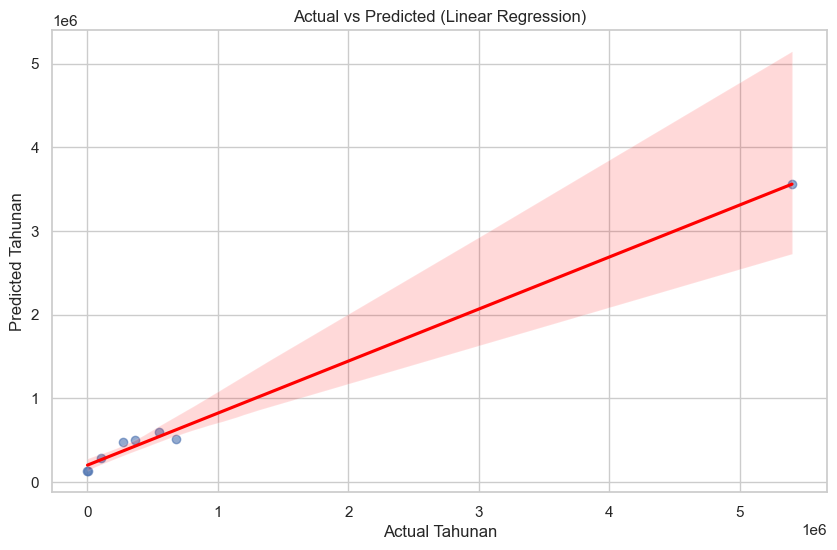

In [7]:
# Plot Hasil Regresi
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Tahunan')
plt.ylabel('Predicted Tahunan')
plt.title('Actual vs Predicted (Linear Regression)')
plt.show()